## Sequence Purchasing Problem

Lead     : `<Alex / AlexLeonardos>`

Issue    : [Github Issue #84](https://github.com/petadex/igem-toronto/issues/) — _Sequence Purchasing Algorithm_

Start    : `2026-08-13`

Script   : `resources\260629_issue84_algoplanning\unified_design.py`


## Background and Motivation

We want to optimize how we purchase DNA sequences by considering the value of Degenerate-Codon Oligo Libraries. We can purchase a sequence where at specific positions, different nucleotide bases can occur at a ratio we define. Using this, we could encode for many similar sequences from a desired cluster even though we only purchased 1 sequence. Therefore, our motivation is to find the best sequence(s) to purchase for our needs. 

There are several factors that we must account for:

1. **Sequence Information Quantity**: We have a limit in terms of how much information can be ordered, not necessarily the number of sequences. This is only quantified on the total sequences ordered over many clusters (libraries), so it's not computed for this algorithm, which outputs the information used in the optimal solution for specific input clusters (libraries).

2. **Sequence Degeneracy**: How many degenerate bases we will allow in any given sequence.

3. **Possible Fragment Synthesis Approaches**: Whether ordering multiple smaller sequences and ligating them together could work. This idea is expanded upon in the *Important Operations section*.

4. **Sequence Coverage**: How many natural amino acid sequences (exist in the PETadex clusters) these purchased DNA sequences cover.

## Problem Statement

We want to create an algorithm that designs the best nucleotide sequence(s) to order by maximizing for coverage over a given library, with a *junk ratio cap* for how much % junk is acceptable.

### Input: 

   1. **FASTA file for Input**: which consists of *aligned, trimmed protein sequences* that represent unique cores extracted from PETadex clusters. This is the output of *Stage 0*, which is described further down the notebook. The n_k at the end of the lines signifies how many natural sequences mapped to this core.  The fact that they are protein sequences is very important, as the algorithm must have a mechanism of *converting from nucleotides to amino acids*. 

Stored in the form:
```
>core1_n3
AAFAAPAGQTNPYARGPNPTAASLEASAGPFTVRSFTVSRPSGYGAGTVYYPTNAGGTVG
AIAIVPGYTARQSSIKWWGPRLASHGFVVITIDTNSTFDYPSSRSSQQMAALRQVASLNG
DSSSPIYGKVDTARMGVMGHSMGGGASLRSAANNPSLKAAIPQAPWDSQTNFSSVTVPTL
IFACENDSIAPVNSHALPIYDSMSRNAKQFLEINGGSHSCANSGNSNQALIGKKGVAWMK
RFMDNDTRYSTFACENPNSTAVSDFRTANCS-
>core2_n2
AVSAAATAQTNPYARGPNPTAASLEASAGPFTVRSFTVSRPSGYGAGTVYYPTNAGGTVG
AIAIVPGYTARQSSIKWWGPRLASHGFVVITIDTNSTLDQPSSRSSQQMAALRQVASLNG
TSSSPIYGKVDTARMGVMGWSMGGGGSLISAANNPSLKAAAPQAPWDSSTNFSSVTVPTL
IFACENDSIAPVNSSALPIYDSMSRNAKQFLEINGGSHSCANSGNSNQALIGKKGVAWMK
RFMDNDTRYSTFACENPNSTRVSDFRTANCS-
```

1. Use psycopg2 or something similar for the SQL download
2. Fold the sequences - probably use the API folding script for this because it'd probably ok
3. Use some sort of package that extracts domains from pLDDT (finding linker regions)
4. Keep the inner important regions - is this a single domain or multiple domains?

   1. **Junk Ratio Cap**: A scalar value in (0, 1) to determine what the maximum % of junk we would like to allow. This means that the algorithm must have a *manner of keeping track of how many possible proteins could be encoded for by the current solution*, which can be used to compute the junk ratio (how many aren't targets).
   2. **Fragment Joining Method**: This is either Golden Gate or Homologous Recombination. This defines what the junctions would be defined as. Note that due to these techniques and general plasmid design we are under the following hard constraints:

      1. **CGTCTC** and **GAGACG** are BANNED from occuring ANYWHERE in the sequence.
      2. No internal CGGA or GGTG overhangs for cuts as the backbone uses those two overhangs. 
   3. **K-Max**: $K$ is defined as 1 + the number of Golden Gate cuts made. This is looped over in the algorithm to test different amounts of fragmentation.

### Output:

   1. The sequence(s) to order - this is in nucleotide bases.
   2. Indication of which positions have degen codons, fragments, and how much junk this generates.
   3. >TODO: Add metrics relating to the wet lab protocol (how many plates necessary)


# Important Operations

These are the operations that can be used to design a sequence. The algorithm should consider these in some form when designing the final sequence over an input library.

1. **Degenerate Codons**: When at a certain index, there are several possibilities for nucleotide bases.
2. **Fragments**: Multiple shorter fragments can be ligated together by specific junctions. This allows for consideration of library sequences of different lengths, or for protein differences that can't be efficiently encoded for using degenerate codons.

# Short Summary of Previous Work and Novelty:

Existing degenerate codon algorithm papers such as [SwiftLib (2015)](https://academic.oup.com/nar/article/43/5/e34/2453167), and [DeCoDe (2020)](https://pmc.ncbi.nlm.nih.gov/articles/PMC7267834/) share the goal of maximizing coverage of a target library using minimal purchases, but only use degenerate codons to introduce variation. 

[GGAssembler (2024)](https://onlinelibrary.wiley.com/doi/full/10.1002/pro.5169) introduces fragment assembly but has different input and output goals to our algorithm. Specifically, the diversity input into their algorithm is position-specific, whereas our diversity occurs on the sequence level. This introduces the notion of junk to our problem, which is discussed in the next section.

This algorithm's novelty therefore comes in the fact that it considers both operations in designs to maximize coverage. In further testing, potentially beyond the scope of iGEM, this should be compared against DeCoDe and SwiftLib in terms of runtime and approximation ratio.

One other paper is of particular note, that being [RASPP (2004)](https://academic.oup.com/peds/article/17/7/589/1553338). We borrow their graph formulation for site-directed recombination. This paper observes that choosing cuts to split the sequences into for fragment assembly can be represented as finding paths in a graph where cut sites are nodes, fragments are edges, and the edges are weighted by chosen metrics (disruption energy in the original paper). We modify this formulation slightly, as described in the implementation section.

# Key Definitions:

Let $L_T$ be our target library of cores. This is a weighted set, with each $s \in L_T$ having a weight $w(s)$. 

*Justification for $w(s)$*: In preprocessing before the algorithm, many of the ORFs contain the exact same core sequence. The weight is defined as the number of natural ORFs that are behind the core $s$. This allows for maximization of natural sequence count, but does not change the number of unique cores ordered. Instead, it allows us to choose which cores to include. This is justifiable, as a core observed in more ORFs is more likely to be valid and not an assembly artifact/outlier.

Let $L_O$ be the protein library encoded by our algorithm's output sequences. This is a cartesian product across fragments and degenerate codons, meaning that it grows quickly with the number of variations added.

1. **Coverage**: A core $s \in L_T$ is *covered* if $s \in L_O$. 
   Therefore, the total coverage is defined as $\frac{\sum_{s \in L_O \cap L_T} w(s)}{\sum_{s \in L_T} w(s)}$. This is weighted by $w(s)$.

2. **Junk**: This loosely means useless sequences. This can be split into two different type of junk, minimized at different points in the algorithm.

   a. **Counting Junk**: This is $1 - \frac{|L_T \cap L_O|}{|L_O|}$. In English, this is the proportion of our output library that's *not* covering a sequence in the target library. This is the junk that represent the cap in the initial stage of the algorithm. Note that this junk cap is not a quality metric, it is a feasibility constraint. It is also not weighted, as the entries of $L_O$ do not have inherent weights, which are relevant for coverage.

   b. **Mass Junk**: This is the probability mass of landing on non-targets. This can be influenced by *custom degenerate codon ratios*, which are a future direction for optimizing in specific species. Custom ratios cannot change $L_O$, only the distribution over it — so mass junk is optimized on the support fixed by stage 1, leaving coverage and counting junk unchanged. Note that counting junk is a special case of mass junk, under the assumption that the output library is uniformly distributed.

# Current Implementation (August 15th, 2026):


### **Stage 0. Preprocessing:** (August 19th, 2026)

This preprocessing takes in raw 90pid clusters from the PETadex, and processes them into the aligned fasta format with weights that is input for Stage 1. The ORFs in their raw state contain unwanted information such as tags, signal peptides, linkers, and fusion partners surrounding the domain(s) of interest. Additionally, some ORFs in the clusters may be truncated fragments, which we want to account for.

Note that the 90pid clusters are clustered based on 90pid within the PETadex HMM hit region. These PETadex HMMs are built from the corpus of sequences in the entire component, and therefore are not guaranteed to cover the full domain. Since these are sequences we want to order, we would like to synthesize the full regions rather than only the PETadex HMM hit region, motivating this preprocessing.

First, the clusters are pulled from the PETadex SQL using a standardized psycopg2 script. (Expand on this later). This gives us the set of ORFs, as well as indication of which ORF represents the centroid for this cluster.

The following steps cover two possible implementations that we will compare with each other to see if they agree, to decide which to ultimately use.

#### Preprocessing Plan 1: Full Folding

This approach folds the ORFs using the ESMFold2 script run on a VM, and receives the structure and quality metrics. 

python ../esmfold2_local_predictor.py     cluster_orfids/clusters/1/centroid.fa     --dtype fp32 --num-sampling-steps 68 --num-loops 10     --hf-cache ../hfcache --s3 s3://petadex-protein-structures/esmfold2_clusters/90pid/1/     --outdir out/clusters/1/fold/

The structure can be uploaded to S3 for potential future use, but the PAE/pLDDT scores can be analyzed to scan for the presence of domains. This can either be implemented using a pre-implemented tool, or a custom script. Once these domains are identified, they are aligned using an MSA to produce the input fasta.

This plan values per-ORF boundaries, and may be preferred if the cost of folding everything is not too high.

- If accuracy is low for this method, we could augment it with pfam domain checks, or regex checks for other common tags.

#### Preprocessing Plan 2: Centroid-Only Folding + Cluster HMMs

This approach uses the folding plan, but only on the centroids of the clusters. Once we have a processed, trimmed sequence of the centroid, we align everything in that cluster to it using an MSA. Finally, we build a cluster-specific HMM from this MSA. This cluster-specific HMM allows us to identify matches, insertions, and deletions. This allows us to select a cutoff for how much matching to allow. 

Note that these cluster-specific HMMs are hypothesized to be much more accurate than the PETadex HMMs, but they may still cut off important regions, especially if the centroid holds a smaller domain. This would lead to silent failures.

This plan values efficiency, while using a centroid-derived boundary. On high scales, folding every protein might not be feasible, justifying the need for this approximation.

### **Stage 1. Operation Context:**

This stage provides the context for our operations (computes the IUPAC codon table for eventual degenerate codon computation accounting for stop codons, amino acid set, where Golden-Gate junctions could actually occur, under the provided restrictions). No decisions are made at this stage, it only makes pricing a move in Stage 2 constant time. 


### **Stage 2. Greedy:**

Start with an existing core in the library, specifically the one that covers the most natural sequences. This was chosen as an easy starting point, that guarantees the most coverage to start.

The core idea of the algorithm is to use a greedy nested loop which repeatedly chooses cores to add that minimize junk per newly encoded natural sequence.

The outermost loop loops over $K$ which defines how many fragments make up a single full sequence (# of cuts + 1). 
  - Per iteration, $place\_cuts(K)$ is called, which returns a segmentation found through backtracking DFS on a graph formulation of this problem inspired by RASPP (2004) (nodes-cut sites, edges - fragments, weights - library size rather than structural disruption). 
  - Additionally, our $place\_cuts(K)$ helper must adhere to the junctions being unique for GGA, and uses the results of Stage 1 to assess valid junctions.
  - Note that finding a single path in this network only finds one possible cut configuration, and shorter paths accumulate less total library size. This was chosen intentionally as an approximation for this first implementation.

Once a particular cut is defined (approximation choice), the innermost loop loops over uncovered cores and computes the cost of incorporating them into the design. 
  - This considers reusing existing fragments, widening a fragment with degenerate codons, or buying a new fragment, while also computing junk introduced. 
  - As previously mentioned, the scoring function is junk per newly encoded natural sequence count, which is minimized. 
  - Ties are broken by choosing the option that adds less nucleotides.
  - The best core is repeatedly chosen in this process, with costs being recomputed after every choice.
  - Stage 2 stops when no core can be added without going over the junk cap. 
  - This computation is done over amino acids, but a reverse mapping is done to check for forbidden recognition sites through a sliding window check.

### **Stage 3. Materialize:**

Turn the design into a concrete set of DNA fragments to order. Check again that no forbidden recognition sites occur.

Output the proper metrics and the variation introduced, over the different K values. Choose the one with the best balance sequence number-per-kilobase.


## Key Current Approximation:

The fact that cuts are fixed before core selection in the greedy loop is a key limitation of the algorithm. This was done to make the search space easier to iterate over, even if it restricts some possibilities. Future work could go into how to augment this architecture, so that the cuts aren't chosen with the assumption that they're all kept.

# Runtime:

This will be a short cell as the full runtime justification would be very lengthy. However, it can be observed through the loop structure that the final algorithm is cubic in the number of cores, and linear in alignment width. This is an improvement over the exponential search space.

# Example: 

The following is an LLM-generated summary of results from 2 example 90pid clusters. These simple test cases that will be replaced by wider testing on the PETadex in the future. This is just justification that the algorithm works on a small example.

## Smoke Test Results

Run on the two iSPETase clusters, Golden Gate chemistry, junk cap 80%:

```bash
python unified_design.py ../../ninetypidorfs/cluster2.core.aln.fasta --chemistry gg --k-max 6
```

**cluster2** — 41 unique cores (153 natural sequences), 290 alignment columns:

```
   K      cores     nat seqs      library    junk%   oligos        nt   seq/kb
   1   41/41      153/153              41     0.0%       37    28,410     5.39
   2   31/41      143/153             154    79.9%       26    12,801    11.17
   3   20/41      132/153             100    80.0%       19     5,346    24.69  <== recommended
   4   17/41       81/153              65    73.8%       20     3,915    20.69
   5   17/41       81/153              65    73.8%       21     3,915    20.69
   6   17/41       81/153              65    73.8%       22     3,483    23.26
```

### The actual order

The recommended design is 19 oligos totalling 5,346 nt. Fragment 2 is a single
oligo and is shown in full; the manifest below covers the rest.

```
>frag2_oligo1
GAAGCAGCAATACCACTACAAGGATGGCACACAAGAAAAAACTGGAGCAGCGTAAGAACT
```

| fragment | oligos | length range | degenerate codons |
|---|---|---|---|
| 1 | 8 | 306–573 nt | `RAC` (Asn/Asp), `KCA` (Ala/Ser) |
| 2 | 1 | 60 nt | — |
| 3 | 10 | 171–237 nt | — |

Only two positions in the whole design carry a degenerate codon, each collapsing
two cores into one oligo: `RAC` encodes Asn **or** Asp, `KCA` encodes Ala **or**
Ser. Every other oligo is a fixed sequence.

Junctions: overhang `TAGA` before residue 191, `CTCC` before residue 211.
The complete sequences are in `fragment1.fasta`, `fragment2.fasta`,
`fragment3.fasta` in the run directory.


**cluster1** — 62 unique cores (66 natural sequences), 272 alignment columns:

```
   K      cores     nat seqs      library    junk%   oligos        nt   seq/kb
   1   62/62       66/66               62     0.0%       58    46,623     1.42
   2   37/62       41/66              165    77.6%       34    21,924     1.87
   3   25/62       29/66              114    78.1%       23     9,945     2.92
   4   25/62       29/66              114    78.1%       24     9,519     3.05
   5   25/62       29/66              114    78.1%       25     9,324     3.11
   6    6/62        8/66               18    66.7%       13     2,163     3.70  <== recommended
```

**What these confirm:**

1. **The junk cap is honoured in every design** — nothing exceeds 80%, and most designs sit just under it, which is what a feasibility constraint should look like.
2. **Degenerate codons are used, and here they are free.** At $K = 1$, cluster2 encodes all 41 cores with 37 oligos and cluster1 all 62 with 58 — both at 0% junk. Those are widen moves covering two cores with one oligo wherever they differ at a single codon-expressible position.
3. **The Golden Gate designs are buildable as emitted.** Every junction overhang is non-palindromic, GC-balanced, mutually orthogonal, and distinct from the reserved backbone overhangs, and the assembled full-length examples contain no forbidden recognition site.
4. **The recommender rule is the weak point.** Sequences-per-kilobase is a ratio, so it rewards small orders: on cluster1 it recommends $K = 6$, which encodes only 8 of 66 natural sequences. Until that rule is settled, the frontier table is the honest output and the single recommendation should not be read as a decision.


## For Future Work:

These are ideas that would be nice to have in a complete, publishable version of this algorithm. For this first pass of sequence purchasing, they do not need to be explicitly considered.

1. Structural Modelling - Accounting for if RNA structures (hairpins) make the sequence infeasible. This was previously a main feature of the algorithm's design, but has since been removed.
2. Proofs about Approximation Ratios if possible.
3. **Custom Codon Ratios**: Which ratio of bases at these positions would maximize the amount of natural sequences synthesized and minimize the amount of artificial ones that aren't biologically existing.

    - Computed using Lisa's *scoring function*. This considers the codon table for specific vectors which assays would take place using.
    - Max 4 custom ratio bases according to Twist, although we may be able to pay for more
        - IUPAC Standard 50/50 combinations don't count towards this custom ratio count

# Test On Halo Assay Synthesized Sequences

Per Artem's request, I have run the algorithm on the sequences synthesized for the Halo Assay in the Logan paper.

Data: aws s3 cp s3://petadex/logan/haloAssay/logan.haloAssay.v241123.msta.fa ./ --no-sign-request - August 22nd 2026.


Ok so I ran the algo on s3://petadex/logan/haloAssay/logan.haloAssay.v241123.msta.fa and the results make sense as a negative control. There's only 1 junction throughout the protein set, so there's only 2 possibilities, including the cut or not. I'll just put the results in tables because there's only 2 K values, but I want to do more testing this weekend on the preprocessing so there will be figures for that.
Junk Cap 80%:
   K      cores     nat seqs      library    junk%   oligos        nt   seq/kb
   1  199/199     199/199             199     0.0%      199   192,180     1.04
   2    5/199       5/199              25    80.0%       10     3,618     1.38  <== recommended
Junk Cap 99.6%
   K      cores     nat seqs      library    junk%   oligos        nt   seq/kb
   1  199/199     199/199             199     0.0%      199   192,180     1.04
   2  199/199     199/199          38,805    99.5%      394   190,128     1.05  <== recommended
So this test shows that for a protein set that can't be encoded reasonably using fragments or degenerate codons, the algorithm finds the trivial solution of ordering all of the sequences. While using fragments/degen codons is technically possible, this is a 2000 nucleotide save with 99.5% junk.
One other conclusion from this, I don't think seq/kb is the best metric for choosing the output. Both outputs recommended the worse solution in my opinion. We could either create a better metric, or because we won't be running the algorithm on many clusters, manually examine the best solution graphs over K and choose an appropriate one.






# Updates: August 25th, 2026

Change to the Greedy Metric and Caps: Before it was junk gain / natural sequence gain. This was tie broken by nt additions. Now we have to ensure both that the whole thing isn't degenerate codons, but also that the nt choices are reasonable.
- Because we are enforcing a library size cap now, the metric should be change in library size / gain. This ensures that adding sequences occupies the least space in the potential library size as possible, leaving the door open for more natural sequence additions in future iterations.

Change to the Cut Selection:
- 1 cut per K isn't enough to be defensible. The cut graph searching allows us to minimize the product of per-layer distinct piece counts, given an input K. This is useful because there's a different number of unique fragments around each of the cuts in their different configurations, so choosing good cuts allows us to choose cuts that better let us minimize the library size if every natural piece were ordered as its own oligo without degenerate codons. This also maximizes the chances that the full library can fit under the library size cap.
- One other thing to realize is that while the graph-based cut selection is justifiable, it finds very similar solutions ultimately. Additionally, while the graph solution is theoretically a good choice we have no guarantee that it will lead to an optimal solution after greedy. The greedy loop doesn't take very long to compute, which motivates us to attempt many random cuts as well as the graph solution.
- Experiment justification goes here. Based on tests on cluster 1 and 2, 5 proxy cuts and 45 random cuts are justifiable and don't take unreasonable runtimes. Additionally, we must note that there is a min cut distance for the random cuts, to avoid fragments being too short.

Change to Validation:
- Validation.py script is now in place with no shared code as the standard algorithm. Many things to check, will be written out independently.
No more major changes to the algorithm after tonight.

Check Schema: Aligns to the following specifications as specified by the Wet Lab Manifesto:

```
Hard constraints (read before ordering anything)
Do not put the BsmBI site CGTCTC or its reverse complement GAGACG anywhere inside a fragment.
No in-frame stop codons.
Reserved overhang junctions. CGGA is the backbone-to-first-fragment junction and GGTG is the last-fragment-to-backbone junction. Do not reuse either as an internal junction.
Inserts are the amplified Dry Lab fragments with BsmBI sites on each end. Add a standard sequence to each end when ordering so a single primer set works for every fragment (this avoids ordering new primers per sequence). (like this attached image)
```

Codon Selection: If this isn't already accounted for by Twist Algorithms, this algorithm codon optimizes. Codon choices for DNA are consistent with the Kazusa *E. coli* W3110 table. This K-12 derivative was chosen as it is built from far more data than the BL21-specific entry on Kazusa, while retaining similar expression numbers. Using the *E. coli* B [gbbct] entry could introduce sampling noise as it is only built from 11 CDSs, which is 3,771 codons total.

# Final (hopefully) Algo Updates

### Additional Banned Junctions and Recognition Sites - DONE

- iGEM banned overhang junctions. We can't include these in any of the designs, as they are reserved for the iGEM wet lab protocol which we need to adhere to.

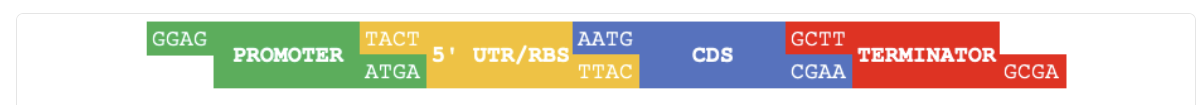

- BSAI restriction enzyme recognition sequence (5'-GGTCTC-3'). This also shouldn't be in the designs, to keep our downstream products free to be used in potential future study. BSAI is commonly used in Golden-Gate assays, so it is useful to leave this open if possible.

### Post-processing script - DONE

- Needs to add:
  - the BSMBI recognition site
  - the appropriate cut sites
  - spacer sequences as required

Please Note:
  - 5' cgga-----------------------------------ggtg 3' needs to be the overhangs relative to the backbone (the first layer fragments need cgga and the last layer fragments need ggtg). 

Side note: future augmentation to the algorithm could ignore finding the existing junctions in the sequence and do a more expensive DP to find the most optimal cut sites to minimize variation within each layer. The overhangs could theoretically be provided around each of the fragments. 
- The current implementation is fine though, I think that the simplification to cuts only around the existing cut sites is fine for now, and the DP solution is scalable anyways.

FINAL ADDITIONS:

Before layer 1 is "CGTCTC (BsmBI) + C(spacer) + CGGA (backbone overhang)". Note that there is NO padding that I need to do, the backbone design handles it. After the last layer should be "GGTG(backbone overhang) + C(spacer) + GAGACG(BsmBI, reversed)".

For the inner Junctions, include the recognition site, C as a spacer, and then the appropriate half of the overhang (2 nt). This will be the overhang, and when they combine, no amino acids will change or frameshifts will occur.

### Spreadsheet output script - DONE

- Convert the fragments to a csv so that they can be ordered more easily

### Script that runs the pipeline easily - Tomorrow

- This is so that it can be put on a VM or something and run for all of the clusters we want

### Figures Scripts Prototypes (to show Thomas on Saturday) - Tomorrow/Thursday

- Run these on the IsPETase cluster rerun and have scripts for generating them

- In the final figures plan

### Fold 100 of the full sequences and send them to thomas to look over

# Algorithm Running Instructions

These steps assume that the input fasta is already valid. Therefore, the following only includes the algorithm itself and postprocessing.

**Dependencies**

- **Python 3.9+**
- **No third-party packages.** The designer, the validator and the post-processing
  are standard library only.
- The scripts in `resources/260629_issue84_algoplanning/final/`: `_paths.py`,
  `cutsearch_design.py`, `dp_cutsearch.py`, `validate_design.py`,
  `annotate_degenerate.py`, `make_order.py`
- Correct Input: One **aligned core FASTA** per cluster, gaps as `-` and headers `>coreN_n<k>`

### 1. Design

```bash
cd resources/260629_issue84_algoplanning/final

python cutsearch_design.py ../stage0_cluster1/out/clusters/1/c1.core.aln.fasta \
    --chemistry gg \ # we only use golden gate here, not homologous recombination
    --cut-search dp \
    --max-library 2500 \
    --max-nt 45000 \
    --k-max 10 \
    --seed 0 \ # seed for cutsearch
    --out-dir ../algoruns/out
```

This command writes a text summary (`report.txt`), a JSON with metrics (`summary.json`), an example full-length DNA, and `fragment<N>.fasta` which contains the actual oligo sequences.

### 2. Validate — always, before ordering

```bash
RUN=../algoruns/out/20260908_210646_c1.core.aln_gg_unified

python validate_design.py $RUN
```

This file does 18 independent checks, including checking overhang legality and orthogonality, scanning for forbidden sites inside oligos and across junctions, and recomputing coverage, reading frame, stop codons, true library size, the caps,
and synthesis constraints.

### 3. Annotate the degenerate codons (optional)

```bash
python annotate_degenerate.py $RUN
```

Adds `degenerate_codons.tsv` (every IUPAC position, its expansions, and the amino
acids it encodes) and `fragment<N>.annotated.fasta`. This is optional, it was implemented to better see how many degenerate codons were added to a design at a glance.

### 4. Post-process into order-ready constructs

```bash
python make_order.py $RUN
```

Performs the postprocessing (adding Golden Gate sites as described above). This script outputs `constructs.csv` (csv of sequences and what was added to the fragments + why), `constructs_simple.csv` (name, sequence to order), `constructs.fasta` (contains the same info in fasta format),  and a report text file. This is all found in the `run/order/` directory.

# Citations

Codon usage frequencies for Escherichia coli W3110 (NCBI taxid 316407; 4,332 CDSs, 1,372,057 codons) were obtained from the Codon Usage Database (Nakamura et al., 2000; https://www.kazusa.or.jp/codon/cgi-bin/showcodon.cgi?species=316407, accessed August 27th, 2026).

Hoch SY, Netzer R, Weinstein JY, Krauss L, Hakeny K, Fleishman SJ. GGAssembler: Precise and economical design and synthesis of combinatorial mutation libraries. Protein Science. 2024; 33(10):e5169. https://doi.org/10.1002/pro.5169

Jeffrey B. Endelman, Jonathan J. Silberg, Zhen-Gang Wang, Frances H. Arnold, Site-directed protein recombination as a shortest-path problem, Protein Engineering, Design and Selection, Volume 17, Issue 7, July 2004, Pages 589–594, https://doi.org/10.1093/protein/gzh067

Nakamura Y, Gojobori T, Ikemura T. Codon usage tabulated from international DNA sequence databases: status for the year 2000. Nucleic Acids Research 2000;28(1):292. doi:10.1093/nar/28.1.292. PMID 10592250; PMCID PMC102460.

Shimko TC, Fordyce PM, Orenstein Y. DeCoDe: degenerate codon design for complete protein-coding DNA libraries. Bioinformatics. 2020 Jun 1;36(11):3357-3364. doi: 10.1093/bioinformatics/btaa162. PMID: 32176271; PMCID: PMC7267834.

Timothy M. Jacobs, Hayretin Yumerefendi, Brian Kuhlman, Andrew Leaver-Fay, SwiftLib: rapid degenerate-codon-library optimization through dynamic programming, Nucleic Acids Research, Volume 43, Issue 5, 11 March 2015, Page e34, https://doi.org/10.1093/nar/gku1323